In [25]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from transformers import EarlyStoppingCallback
import numpy as np
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [26]:
df = pd.read_csv('/kaggle/input/datasets/aliabdelmenam/emotion-dataset/cleaned_emotions_data.csv')

In [27]:
df.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,text_cleaned
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0.0,0.0,1,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1.0,"""If wear BROWN ORANGE...YOU MATTER!"" need tshi..."
1,"""What do Scottish people look like?"" How I wo...",0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,"""What Scottish people look like?"" would love t..."
2,"### A surprise, to be sure, but a welcome one",0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.0,"### surprise, sure, welcome one"
3,"'*Pray*, v. To ask that the laws of the unive...",0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1.0,"'*Pray*, v. ask laws universe annulled behalf ..."
4,">it'll get invaded by tankie, unfortunately. ...",0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1.0,">it'll get invaded tankie, unfortunately. apro..."


In [28]:
df.sample(1)['text_cleaned'].values

array(['feeling artistic time life'], dtype=object)

In [29]:
sentence_lengths = df['text_cleaned'].astype(str).apply(len)
sentence_length_counts = sentence_lengths.value_counts(ascending=False).sort_index()
display(sentence_length_counts)

text_cleaned
1         3
2        17
3       107
4       195
5       215
       ... 
493       1
505       1
526       1
685       1
1289      1
Name: count, Length: 274, dtype: int64

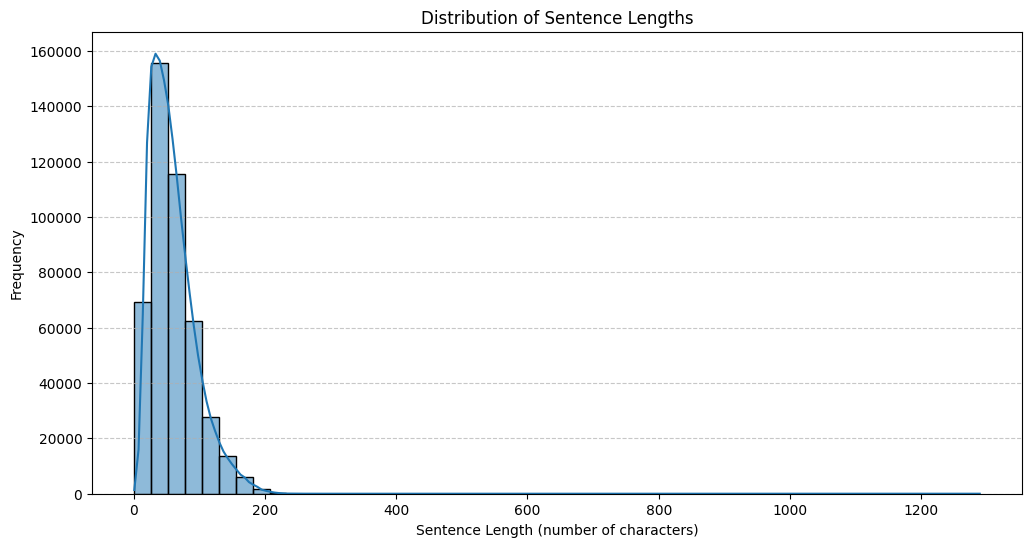

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(sentence_lengths, bins=50, kde=True)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Sentence Length (number of characters)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [31]:
print(f"60th percentile: {sentence_lengths.quantile(.60)}")
print(f"70th percentile: {sentence_lengths.quantile(.70)}")
print(f"80th percentile: {sentence_lengths.quantile(.80)}")
print(f"85th percentile: {sentence_lengths.quantile(.85)}")
print(f"90th percentile: {sentence_lengths.quantile(.90)}")
print(f"95th percentile: {sentence_lengths.quantile(.95)}")
print(f"99th percentile: {sentence_lengths.quantile(.99)}")

60th percentile: 61.0
70th percentile: 72.0
80th percentile: 85.0
85th percentile: 95.0
90th percentile: 107.0
95th percentile: 128.0
99th percentile: 168.0


In [32]:
from scipy.stats import percentileofscore

# @title Enter a sentence length to find its percentile
length_to_check = 128 # @param {type:"number"}

percentile = percentileofscore(sentence_lengths, length_to_check)
print(f"A sentence length of {length_to_check} characters is at the {percentile:.2f}th percentile.")
print(f"This means approximately {percentile:.2f}% of sentences have a length of {length_to_check} characters or less.")

A sentence length of 128 characters is at the 94.97th percentile.
This means approximately 94.97% of sentences have a length of 128 characters or less.


In [33]:
INPUT_LENGTH = 128

In [34]:
# Define a function to truncate or pad the text
def fix_text_length(text, target_length=INPUT_LENGTH, padding_char=' '):
    if len(text) > target_length:
        return text[:target_length]
    else:
        return text.ljust(target_length, padding_char)

# Apply the function to the 'text' column, ensuring all values are strings
df['text_fixed_length'] = df['text_cleaned'].astype(str).apply(fix_text_length)

# Display some examples to verify
print("Original text length:")
display(df['text_cleaned'].astype(str).apply(len).head()) # Fixed line
print("Fixed text length:")
display(df['text_fixed_length'].apply(len).head())

print("Original and Fixed Text Examples:")
display(df[['text', 'text_fixed_length']].sample(5))

Original text length:


0    54
1    65
2    31
3    96
4    50
Name: text_cleaned, dtype: int64

Fixed text length:


0    128
1    128
2    128
3    128
4    128
Name: text_fixed_length, dtype: int64

Original and Fixed Text Examples:


,text,text_fixed_length
331224,i ought tofeel frightened but i really feel as...,ought tofeel frightened really feel brave ox ...
217948,i feel reluctant and fear i know the answer al...,feel reluctant fear know answer already ...
408453,i write at my weekend office panera bread i us...,write weekend office panera bread usually haze...
194054,i feel like ive been emotionally drained,feel like ive emotionally drained ...
441349,is feeling it got emotional for yuki when conf...,feeling got emotional yuki confront love jealo...


In [35]:
# Identify emotion label columns (excluding 'text', 'text_cleaned', 'text_fixed_length')
# Assuming emotion columns are all columns from 'admiration' to 'neutral'
emotion_columns = df.columns.difference(['text', 'text_cleaned', 'text_fixed_length'])

# Calculate the sum of emotion labels for each row
df['label_sum'] = df[emotion_columns].sum(axis=1)

# Find rows where the sum of labels is 0
rows_without_labels = df[df['label_sum'] == 0]

print(f"Number of rows without any active emotion label: {len(rows_without_labels)}")

if not rows_without_labels.empty:
    print("\nExamples of rows without labels (first 5):")
    display(rows_without_labels[['text', 'label_sum']].head())

Number of rows without any active emotion label: 0


In [36]:
df.head()

,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,pride,realization,relief,remorse,sadness,surprise,neutral,text_cleaned,text_fixed_length,label_sum
0,"""If you don't wear BROWN AND ORANGE...YOU DON...",0.0,0.0,1,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,1.0,"""If wear BROWN ORANGE...YOU MATTER!"" need tshi...","""If wear BROWN ORANGE...YOU MATTER!"" need tshi...",5.0
1,"""What do Scottish people look like?"" How I wo...",0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0,0,0.0,"""What Scottish people look like?"" would love t...","""What Scottish people look like?"" would love t...",2.0
2,"### A surprise, to be sure, but a welcome one",0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,1,0.0,"### surprise, sure, welcome one","### surprise, sure, welcome one ...",1.0
3,"'*Pray*, v. To ask that the laws of the unive...",0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,1.0,"'*Pray*, v. ask laws universe annulled behalf ...","'*Pray*, v. ask laws universe annulled behalf ...",1.0
4,">it'll get invaded by tankie, unfortunately. ...",0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0,0,1.0,">it'll get invaded tankie, unfortunately. apro...",">it'll get invaded tankie, unfortunately. apro...",1.0


In [37]:
df.drop(['text','text_cleaned','label_sum'],axis=1,inplace=True)

In [38]:
df.head()

,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,text_fixed_length
0,0.0,0.0,1,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0,0,1.0,"""If wear BROWN ORANGE...YOU MATTER!"" need tshi..."
1,0.0,0.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0.0,"""What Scottish people look like?"" would love t..."
2,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,1,0.0,"### surprise, sure, welcome one ..."
3,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1.0,"'*Pray*, v. ask laws universe annulled behalf ..."
4,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0,1.0,">it'll get invaded tankie, unfortunately. apro..."


# Fine-Tunning

In [39]:
class EmotionDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len, label_columns):
        self.len = len(dataframe)
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.label_columns = label_columns

    def __getitem__(self, index):
        # 1. Get the text
        # Use TEXT_COLUMN instead of a hardcoded 'text'
        text = str(self.data.iloc[index][TEXT_COLUMN])

        # 2. Tokenize the text
        # This handles the padding and truncation automatically
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length', # Pads to max_len
            truncation=True,      # Truncates to max_len
            return_attention_mask=True,
            return_tensors='pt'
        )

        # 3. Get the labels (One-Hot Vector)
        # We extract the values from the specific label columns
        labels_row = self.data.iloc[index][self.label_columns]
        labels = labels_row.values.astype(float)

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(labels, dtype=torch.float) # Must be float for multi-label
        }

    def __len__(self):
        return self.len

In [40]:
# Assuming your dataframe is named 'df'
# If your text column is named differently, change 'text' below
TEXT_COLUMN = 'text_fixed_length'

# Automatically detect label columns (everything except the text column)
label_columns = [col for col in df.columns if col != TEXT_COLUMN]
num_labels = len(label_columns)

print(f"Number of labels detected: {num_labels}")
print(f"Labels: {label_columns}")

# Split into Train and Validation sets
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# Initialize Tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Create Dataset objects
MAX_LEN = 128 # You can adjust this based on your text length
train_dataset = EmotionDataset(train_df, tokenizer, MAX_LEN, label_columns)
val_dataset = EmotionDataset(val_df, tokenizer, MAX_LEN, label_columns)
test_dataset = EmotionDataset(test_df, tokenizer, MAX_LEN, label_columns)

Number of labels detected: 28
Labels: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']


In [41]:
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base',
    num_labels=num_labels,
    problem_type="multi_label_classification" # Crucial for multi-label!
)

model.to(device) # Move model to GPU

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [42]:
def compute_metrics(p):
    pred_logits, labels = p

    # Apply Sigmoid to convert logits to probabilities (0 to 1)
    sigmoid = torch.nn.Sigmoid()
    probs = sigmoid(torch.Tensor(pred_logits))

    # Convert probabilities to binary predictions (0 or 1) using threshold 0.5
    preds = (probs > 0.5).int().numpy()
    labels = labels.astype(int)

    # Calculate F1 Score (Macro is good for multi-label imbalance)
    f1 = f1_score(labels, preds, average='macro')

    # Optional: Subset Accuracy (Exact match)
    acc = accuracy_score(labels, preds)

    return {
        'f1': f1,
        'accuracy': acc
    }

In [43]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,              # You increased this to 20
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',

    # --- CORRECTED ARGUMENTS HERE ---
    logging_strategy="epoch",     # Log training metrics at the end of each epoch
    eval_strategy="epoch",        # Changed from 'evaluation_strategy' to 'eval_strategy'
    save_strategy="epoch",        # Save model at the end of each epoch

    load_best_model_at_end=True,  # Reload the best model when training finishes
    metric_for_best_model="f1",   # Use F1 to decide which model is best
    greater_is_better=True,
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [44]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)] # <--- Add this line
)

In [45]:
# Start training
trainer.train()

Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.200518,0.065774,0.373895,0.872033
2,0.062944,0.059326,0.422461,0.877275
3,0.057274,0.056893,0.469476,0.878806
4,0.053422,0.056338,0.487546,0.879784
5,0.050423,0.056713,0.503230,0.880486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=7060, training_loss=0.08491638767145174, metrics={'train_runtime': 24066.7985, 'train_samples_per_second': 75.05, 'train_steps_per_second': 0.293, 'total_flos': 1.1883586092243456e+17, 'train_loss': 0.08491638767145174, 'epoch': 5.0})

In [46]:
import shutil
from transformers import AutoTokenizer
import os

# 1. Save the final model and tokenizer explicitly
# Trainer already saved the best model to ./results, but let's ensure it's clean
model.save_pretrained('./final_model')
tokenizer = AutoTokenizer.from_pretrained('roberta-base')
tokenizer.save_pretrained('./final_model')

# 2. Zip it for easy download
shutil.make_archive('roberta_multilabel_model', 'zip', './final_model')

# 3. List the file so you can see it in the Output tab
print("Model saved and zipped!")
print(os.path.getsize('roberta_multilabel_model.zip') / 1024 / 1024, "MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved and zipped!
436.59387969970703 MB


In [47]:
# This runs the model on test_dataset using GPU automatically
test_results = trainer.evaluate(test_dataset)

print("--- Test Set Results ---")
for key, value in test_results.items():
    print(f"{key}: {value:.4f}")

--- Test Set Results ---
eval_loss: 0.0575
eval_f1: 0.4971
eval_accuracy: 0.8808
eval_runtime: 176.4798
eval_samples_per_second: 204.6980
eval_steps_per_second: 0.8050
epoch: 5.0000


In [50]:
# Run these if you haven't already
!pip install demoji nltk

import nltk
import demoji

# Download necessary data
nltk.download('stopwords')
# demoji.download_codes()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [97]:
import torch
from nltk.corpus import stopwords
import demoji

def predict_emotion(text, model, tokenizer, label_columns):
    """
    Takes raw text, preprocesses it, and returns predicted emotions.
    """
    
    # --- 1. Preprocessing ---
    
    # A. Lower case
    text = str(text).lower()
    
    # B. Convert emojis to text using demoji
    # This replaces '🔥' with 'fire' etc.
    text = demoji.replace_with_desc(text, sep=" ")
    
    # C. Remove stop words
    stop_words = set(stopwords.words('english'))
    words = text.split()
    filtered_words = [w for w in words if w not in stop_words]
    text = " ".join(filtered_words)
    
    # --- 2. Tokenization ---
    
    # Truncation is handled here (max_length=128)
    encoding = tokenizer(
        text,
        add_special_tokens=True,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    # --- 3. Inference ---
    
    # Move inputs to GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    model.eval() # Ensure model is in eval mode
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        # Apply Sigmoid for multi-label probabilities
        probs = torch.sigmoid(logits)
        
        # Apply threshold 0.5
        predictions = (probs > 0.5).int()
    
    # --- 4. Format Output ---
    
    # Convert tensor to list
    predictions = predictions[0].cpu().numpy()
    
    # Map predictions to label names
    result = {}
    for i, label in enumerate(label_columns):
        if predictions[i] == 1:
            result[label] = 1
        else:
            result[label] = 0
            
    return result

In [113]:
# Example usage:
sample_text =  "i have the feeling she was amused and delighted"

# Call the function
predictions = predict_emotion(sample_text, model, tokenizer, label_columns)

print("Input Text:", sample_text)
print("Predictions:", predictions)

# If you only want the active labels:
active_emotions = [k for k, v in predictions.items() if v == 1]
print("Detected Emotions:", active_emotions)

Input Text: i have the feeling she was amused and delighted
Predictions: {'admiration': 0, 'amusement': 0, 'anger': 0, 'annoyance': 0, 'approval': 0, 'caring': 0, 'confusion': 0, 'curiosity': 0, 'desire': 0, 'disappointment': 0, 'disapproval': 0, 'disgust': 0, 'embarrassment': 0, 'excitement': 0, 'fear': 0, 'gratitude': 0, 'grief': 0, 'joy': 1, 'love': 0, 'nervousness': 0, 'optimism': 0, 'pride': 0, 'realization': 0, 'relief': 0, 'remorse': 0, 'sadness': 0, 'surprise': 0, 'neutral': 0}
Detected Emotions: ['joy']


In [59]:
from datasets import load_dataset

ds = load_dataset("dair-ai/emotion", "unsplit")

In [60]:
df = ds['train'].to_pandas()

In [28]:
pip install datasets scikit-learn demoji nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 1.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [61]:
import re
import demoji
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Your cleaning patterns
cleaning_patterns = {
    'URL': r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|www\\.[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}',
    'HTML Tags': r'<[^>]*>',
    'Extra Whitespace': r'\s+',
    'Special Characters': r'[^a-zA-Z0-9\s]'
}

def clean_text(text):
    # 1. lowercase
    text = text.lower()
    
    # 2. convert emoji to text
    text = demoji.replace_with_desc(text)
    
    # 3. apply regex cleaning
    for pattern in cleaning_patterns.values():
        text = re.sub(pattern, ' ', text)
    
    # 4. remove extra whitespace again
    text = re.sub(r'\s+', ' ', text).strip()
    
    # 5. remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [62]:
ds = ds.map(lambda x: {"clean_text": clean_text(x["text"])})

In [63]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'clean_text'],
        num_rows: 416809
    })
})

In [64]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch




In [69]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def predict(texts):
    inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model(**inputs)

    preds = torch.argmax(outputs.logits, dim=1)
    return preds.cpu().numpy()


y_true, y_pred = [], []
batch_size = 64

dataset = ds['train']

for i in range(0, len(dataset), batch_size):
    batch = dataset[i:i+batch_size]
    preds = predict(batch['clean_text'])

    y_pred.extend(preds)
    y_true.extend(batch['label'])


accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("F1-score:", f1)

/tmp/ipykernel_57/3315292285.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Accuracy: 1.1995902199808545e-05
F1-score: 2.101671324925141e-05


In [ ]:
import torch
import re
import demoji
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

cleaning_patterns = {
    'URL': r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|www\\.[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}',
    'HTML Tags': r'<[^>]*>',
    'Extra Whitespace': r'\s+',
    'Special Characters': r'[^a-zA-Z0-9\s]'
}

def clean_text(text):
    text = text.lower()
    text = demoji.replace_with_desc(text)

    for pattern in cleaning_patterns.values():
        text = re.sub(pattern, ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]

    return " ".join(tokens)


# label mapping for dair-ai/emotion
id2label = {
    0: "sadness",
    1: "joy",
    2: "love",
    3: "anger",
    4: "fear",
    5: "surprise"
}


def predict_single(text):
    model.eval()

    text = clean_text(text)

    inputs = tokenizer(
        [text],
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()

    return {
        "label_id": pred_id,
        "label": id2label[pred_id]
    }

In [70]:
model.config.id2label

{0: 'LABEL_0',
 1: 'LABEL_1',
 2: 'LABEL_2',
 3: 'LABEL_3',
 4: 'LABEL_4',
 5: 'LABEL_5',
 6: 'LABEL_6',
 7: 'LABEL_7',
 8: 'LABEL_8',
 9: 'LABEL_9',
 10: 'LABEL_10',
 11: 'LABEL_11',
 12: 'LABEL_12',
 13: 'LABEL_13',
 14: 'LABEL_14',
 15: 'LABEL_15',
 16: 'LABEL_16',
 17: 'LABEL_17',
 18: 'LABEL_18',
 19: 'LABEL_19',
 20: 'LABEL_20',
 21: 'LABEL_21',
 22: 'LABEL_22',
 23: 'LABEL_23',
 24: 'LABEL_24',
 25: 'LABEL_25',
 26: 'LABEL_26',
 27: 'LABEL_27'}

In [71]:
import torch
import re
import demoji
import nltk
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

labels = [
    "admiration","amusement","anger","annoyance","approval","caring","confusion",
    "curiosity","desire","disappointment","disapproval","disgust","embarrassment",
    "excitement","fear","gratitude","grief","joy","love","nervousness","optimism",
    "pride","realization","relief","remorse","sadness","surprise","neutral"
]

id2label = {i: l for i, l in enumerate(labels)}

cleaning_patterns = {
    "URL": r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+|www\\.[a-zA-Z0-9.-]+\\.[a-zA-Z]{2,}",
    "HTML Tags": r"<[^>]*>",
    "Extra Whitespace": r"\s+",
    "Special Characters": r"[^a-zA-Z0-9\s]"
}

def clean_text(text):
    text = text.lower()
    text = demoji.replace_with_desc(text)

    for p in cleaning_patterns.values():
        text = re.sub(p, " ", text)

    text = re.sub(r"\s+", " ", text).strip()
    text = " ".join([w for w in text.split() if w not in stop_words])

    return text


def predict_single(text):
    model.eval()

    text = clean_text(text)

    inputs = tokenizer(
        [text],
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model(**inputs)

    pred_id = torch.argmax(outputs.logits, dim=1).item()

    return {
        "label_id": pred_id,
        "label": id2label[pred_id]
    }

In [81]:
predict_single("What Scottish people look like?\" would love take swing softball.")

/tmp/ipykernel_57/2436123689.py:53: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


{'label_id': 17, 'label': 'joy'}